In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#download the dataset
path=tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)

# Read the dataset 
text = open(path,'r',encoding='utf-8').read()

# convert the text into lowercase

text=text.lower()

# display the 1st 500 character

print(text[:500])

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [4]:
print('total characters: ',len(text))

words = text.split()
print("total words: ",len(words))


total characters:  1115394
total words:  202651


In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
word_index=tokenizer.word_index
vocab_size=len(word_index)+1

print('vocab size: ',vocab_size)

vocab size:  12633


In [6]:
for word,index in list(word_index.items())[:10]:
    print(word,':',index)

the : 1
and : 2
to : 3
i : 4
of : 5
you : 6
my : 7
a : 8
that : 9
in : 10


In [7]:
sequences=tokenizer.texts_to_sequences([text])[0]

print(sequences[:30])

[88, 269, 139, 35, 969, 143, 668, 127, 15, 102, 33, 102, 102, 88, 269, 6, 40, 33, 1268, 350, 3, 199, 63, 3, 3332, 33, 1268, 1268, 88, 269]


In [8]:
lines = text.split('\n')
input_sequences=[]
for l in lines:
    token_list=tokenizer.texts_to_sequences([l])[0]

    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequences.append(n_gram_sequence)
print('total sequences ',len(input_sequences))

total sequences  171312


In [9]:
# part2 --> Train/Test --> LSTM model --> Training

max_sequence_len=max([len(x) for x in input_sequences])

print("Maximum sequence length: ",max_sequence_len)

input_sequences=np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)
print("sequence & words per sequence: ",input_sequences.shape)

Maximum sequence length:  16
sequence & words per sequence:  (171312, 16)


In [10]:
# split into x & y

x=input_sequences[:,:-1]
y=input_sequences[:,-1]
print("x shape: ",x.shape)
print("y shape: ",y.shape)


x shape:  (171312, 15)
y shape:  (171312,)


In [11]:
y=tf.keras.utils.to_categorical(
    y,num_classes=vocab_size
)
print(y.shape)

(171312, 12633)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding,LSTM,Dense


model = Sequential()

model.add(
    Input(shape=(max_sequence_len,)
    )
)

#Embedding Layer
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=100
))

model.add(LSTM(150))

model.add(Dense(vocab_size,activation='softmax'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,907,583 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,483 (12.67 MB)

 Trainable params: 3,321,483 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [15]:
history=model.fit(
    x,y,epochs=2,batch_size=128,validation_split=0.2
)

Epoch 1/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 123s 111ms/step - accuracy: 0.0384 - loss: 6.8956 - val_accuracy: 0.0372 - val_loss: 6.8084
Epoch 2/2
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 249s 233ms/step - accuracy: 0.0612 - loss: 6.4044 - val_accuracy: 0.0728 - val_loss: 6.6283


4 * (input_dim * umits+1)*units

input_dim = 100

units = 150

LSTM Params = 4*((100*150+1)*150)=150,600






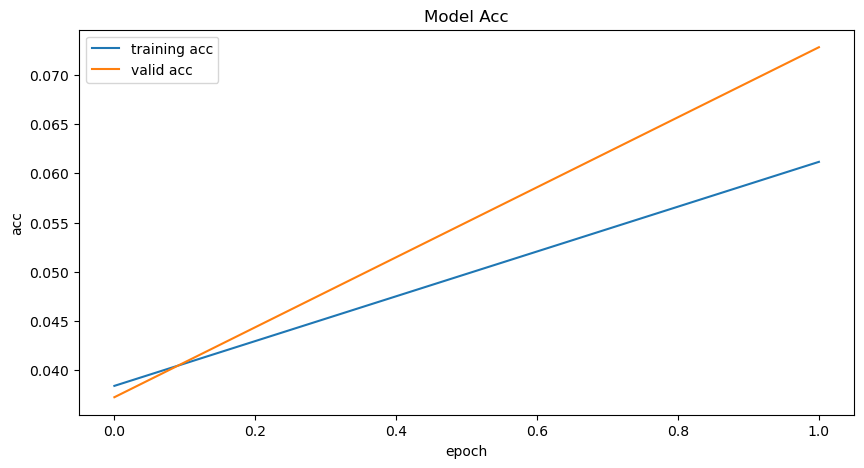

In [16]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Acc')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend(['training acc','valid acc'])
plt.show()

In [17]:
def predict_next_word(seed_text):
    token_list=tokenizer.texts_to_sequences([seed_text])[0]

    token_list=pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding ='pre'
    )

    # predict probabilties 
    predicted = model.predict(
        token_list,verbose=0
    )


    predicted_word_index=np.argmax(
        predicted,
        axis=-1
    )[0]
    output_word=''
    for word,index in tokenizer.word_index.items():
        if index==predicted_word_index:
            output_word = word
            break
    return output_word

In [18]:
seed = "what say you"
next_word=predict_next_word(seed)

print('input ',seed)
print('predicted next ',next_word)

input  what say you
predicted next  have
